# Clase 02. Análisis exploratorio de datos

**INF-396 Introducción a la Ciencia de Datos**
Universidad Técnica Federico Santa María, Departamento de Informática

Repaso de Pandas y primera parte del análisis exploratorio de datos (unidad 2 del programa).

## El concepto de la clase: el análisis exploratorio de datos (EDA)

El concepto central de esta clase es el **EDA**: la etapa en que se examinan los
datos antes de modelarlos. La primera parte de la clase reúne las definiciones
necesarias para hacerlo con rigor: qué es un modelo, la diferencia entre inferencia
y predicción, los coeficientes de correlación, la distinción entre correlación y
causalidad, y los tipos de datos. La segunda parte aplica el EDA a la Encuesta
Origen Destino de Santiago, usando Pandas, que ustedes ya conocen y aquí opera como
herramienta de trabajo.

Una pregunta transversal acompaña ambas partes y reaparecerá durante todo el curso:
cada vez que una cifra resuma datos (un promedio, un porcentaje, un total),
pregúntese **de quién está hablando ese número**. Un promedio puede describir una
situación en la que pocos están; contar filas de una encuesta habla de la muestra y
no de la ciudad; y hay personas de las que la tabla no dice nada, y esa ausencia
también es información.

Las secciones aplicadas se organizan por preguntas sobre los datos; la que las une
viene de la ciudad: **¿cómo se mueve Santiago?**

## Dos definiciones del marco conceptual

En las slides de la clase se desarrollan con detalle; aquí quedan las definiciones
de referencia (James et al., 2023, cap. 2).

**Modelo**: una representación simplificada del proceso que genera los datos.
Formalmente se postula $Y = f(X) + \varepsilon$, donde $f$ es la relación
sistemática que se quiere estimar y $\varepsilon$ el error irreducible. Construir
un modelo implica decidir qué variables entran, qué se omite y qué se considera
éxito; como vimos en la clase 1, esas decisiones incorporan las opiniones de quien
modela.

**Inferencia y predicción**: al estimar $f$ puede buscarse comprender la relación
entre las variables (inferencia: qué se asocia con qué, con qué magnitud y signo) o
estimar $Y$ para casos nuevos (predicción, donde $f$ puede tratarse como caja negra
si acierta). Las unidades 2 a 5 del curso son descriptivas e inferenciales; las
unidades 6 a 9, predictivas.

## Los datos: la Encuesta Origen Destino de Santiago

La **EOD 2012** es la encuesta de movilidad del Gran Santiago, levantada para
[SECTRA](https://www.sectra.gob.cl/biblioteca/detalle1.asp?mfn=3253) por la
Universidad Alberto Hurtado: 18.264 hogares y 60.054 personas, con el registro de
todos los viajes que cada persona hizo durante un día asignado. Se usa en la
planificación de transporte de la ciudad.

Es una base **relacional**: varias tablas que se conectan por identificadores.

| Tabla | Una fila es... | Se conecta por |
|-------|----------------|----------------|
| `Hogares.csv` | un hogar encuestado | `Hogar` |
| `personas.csv` | una persona de un hogar | `Hogar`, `Persona` |
| `viajes.csv` | un viaje de una persona | `Hogar`, `Persona`, `Viaje` |
| `tablas_parametros/` | el significado de cada código | según la tabla |

El mismo diseño aparece en la Casen, el Censo o la ENUSC: los datos en tablas
normalizadas y los significados en tablas de códigos.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 25)

RUTA = "datos/eod_stgo/"

## 1. ¿A quiénes les preguntaron?

Una encuesta responde por su muestra, así que lo primero es saber quién está en ella.
Partimos por la tabla de personas. Repaso breve: `read_csv` con el separador correcto
(estos archivos usan punto y coma, y coma decimal), y las tres miradas iniciales:
`shape`, `head`, `info`.

In [2]:
personas = pd.read_csv(RUTA + "personas.csv", sep=";", decimal=",", low_memory=False)
hogares = pd.read_csv(RUTA + "Hogares.csv", sep=";", decimal=",", low_memory=False)

print(f"Personas encuestadas: {len(personas):,}")
print(f"Hogares encuestados:  {len(hogares):,}")

Personas encuestadas: 60,054
Hogares encuestados:  18,264


In [3]:
personas.head(3)

,Hogar,Persona,AnoNac,Sexo,Relacion,Viajes,LicenciaConducir,PaseEscolar,AdultoMayor,Estudios,Curso,Actividad,...,TieneIngresos,Ingreso,TramoIngreso,IngresoFinal,TramoIngresoFinal,IngresoImputado,Factor_LaboralNormal,Factor_SabadoNormal,Factor_DomingoNormal,Factor_LaboralEstival,Factor_FindesemanaEstival,Factor
0,100010,10001001,1958,1,1,2,3,2,2,4.0,8.0,A,...,1,240000,2,240000,2,0,NaN,NaN,1668.2600,NaN,NaN,82.58553
1,100010,10001002,1956,2,2,5,1,2,2,5.0,1.0,D,...,2,0,0,0,0,0,NaN,NaN,852.1137,NaN,NaN,99.53422
2,100010,10001003,1982,2,3,0,1,2,2,7.0,4.0,A,...,1,99,2,210845,2,2,NaN,NaN,1609.1630,NaN,NaN,151.59367


In [4]:
personas.info()

<class 'pandas.DataFrame'>
RangeIndex: 60054 entries, 0 to 60053
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Hogar                      60054 non-null  int64  
 1   Persona                    60054 non-null  int64  
 2   AnoNac                     60054 non-null  int64  
 3   Sexo                       60054 non-null  int64  
 4   Relacion                   60054 non-null  int64  
 5   Viajes                     60054 non-null  int64  
 6   LicenciaConducir           60054 non-null  str    
 7   PaseEscolar                60054 non-null  int64  
 8   AdultoMayor                60054 non-null  int64  
 9   Estudios                   59932 non-null  float64
 10  Curso                      59932 non-null  float64
 11  Actividad                  57969 non-null  str    
 12  Ocupacion                  25586 non-null  float64
 13  ActividadEmpresa           25586 non-null  float64
 14  J

Dos observaciones antes de seguir.

Primero, `Persona` no es un identificador único por sí solo: se repite entre hogares.
La llave real es el par `(Hogar, Persona)`. Usar una llave incompleta es un error
frecuente y difícil de detectar, porque el merge igual corre.

Segundo, no hay una columna de edad, pero sí el año de nacimiento. La encuesta se
terminó de levantar en 2013, así que **derivamos** la edad como una columna nueva.

In [5]:
personas["Edad"] = 2013 - personas["AnoNac"]
personas["Edad"].describe().round(1)

count    60054.0
mean        37.6
std         22.2
min          0.0
25%         19.0
50%         36.0
75%         54.0
max        109.0
Name: Edad, dtype: float64

### Cómo leer la salida de describe

Las filas de `describe()` son: `count` (observaciones no nulas), `mean` (la media),
`std` (la desviación estándar: cuánto se alejan los valores de la media, en las
mismas unidades de la variable), `min` y `max`, y tres filas de porcentajes que son
los **cuartiles**.

Conviene fijar la terminología, porque los nombres se parecen. **Cuantil** es el
término general: el cuantil $q$ es el valor bajo el cual queda una fracción $q$ de
las observaciones. Según en cuántas partes se corte la distribución, reciben nombres
propios: **cuartiles** (4 partes: el 25%, el 50% que es la mediana, y el 75%),
**quintiles** (5 partes), **deciles** (10) y **percentiles** (100). `describe()`
muestra los cuartiles; los quintiles y deciles no aparecen ahí, pero son los que usa
la política pública chilena para reportar ingresos (la Casen, la asignación de
becas).

Con los valores de arriba, la lectura concreta: la fila `25%  19.0` dice que un
cuarto de los encuestados tiene 19 años o menos; la mediana es 36 (la mitad tiene
esa edad o menos), y tres cuartos tienen 54 o menos. El máximo de 109 años es un
buen candidato a revisar: puede ser real o un error de registro.

### Una nota sobre el DataFrame

Ya trabajan con DataFrames; dos datos que quizás no conocen. El concepto viene del
lenguaje S, donde los objetos `data.frame` aparecen en *Statistical Models in S*
(Chambers y Hastie, 1992); Wes McKinney lo llevó a Python al crear pandas
(McKinney, 2010). Su rendimiento tiene una explicación concreta: cada columna es un
arreglo tipado y contiguo en memoria, como un arreglo de C: todos los valores son del
mismo tipo y se almacenan crudos, uno al lado del otro, a diferencia de una lista de
Python, que guarda punteros a objetos repartidos por la memoria. Por eso una operación
como `.sum()` se ejecuta
como una sola llamada a código compilado que recorre la columna completa (el tipo se
verifica una vez, y como los datos están contiguos, la memoria caché del procesador trabaja a favor). Un ciclo de
Python, en cambio, pasa por el intérprete en cada elemento: verificar el tipo,
desempaquetar el objeto, operar y volver a empaquetar. A eso se refiere el término
**vectorización**. Además, el índice alinea los datos entre tablas, y `merge` y
`groupby` implementan el álgebra relacional en memoria. La misma interfaz la
replican Spark, Polars y Dask.

La diferencia se puede medir con la columna de edades:

In [6]:
import time

col = personas["Edad"]
lista = col.tolist()

def medir(operacion):
    inicio = time.perf_counter()
    operacion()
    return (time.perf_counter() - inicio) * 1000

t_lista = medir(lambda: sum(v for v in lista))
t_columna = medir(lambda: sum(v for v in col))
t_apply = medir(lambda: col.apply(lambda v: v).sum())
t_vec = medir(lambda: col.sum())

print(f"Ciclo sobre una lista de Python:  {t_lista:6.2f} ms")
print(f"Ciclo sobre la columna de pandas: {t_columna:6.2f} ms")
print(f"apply con función de Python:      {t_apply:6.2f} ms")
print(f"Vectorizada (.sum()):             {t_vec:6.3f} ms")

Ciclo sobre una lista de Python:    2.08 ms
Ciclo sobre la columna de pandas:   6.70 ms
apply con función de Python:       19.43 ms
Vectorizada (.sum()):              0.058 ms


Hay un resultado que sorprende: recorrer la columna de pandas con un ciclo es más
lento que recorrer la lista. La razón es el empaquetado: los valores viven crudos en
el arreglo, así que cada vez que el ciclo pide un elemento, pandas debe construirle
un objeto de Python en ese momento; la lista ya tiene sus objetos construidos. Y
`apply` con una función de Python es un ciclo disfrazado, el más lento de todos.

La conclusión: el arreglo tipado y contiguo es condición necesaria pero no
suficiente. La velocidad aparece cuando la operación completa corre en código
compilado (`.sum()`, aritmética entre columnas, `groupby`). Si escribió un `for` o
un `apply` con función de Python sobre una columna, está en el caso lento.

### Los tipos de datos de la encuesta

Antes de resumir una variable hay que saber de qué tipo es, porque el tipo determina
qué operaciones tienen sentido:

| Tipo | Qué es | Ejemplos en la EOD | Resúmenes con sentido |
|------|--------|--------------------|------------------------|
| Categórico nominal | categorías sin orden | `Sexo`, `Comuna`, `Proposito` | conteos y proporciones |
| Categórico ordinal | categorías con orden | `Estudios` (nivel educacional) | conteos, mediana de la categoría |
| Numérico discreto | conteos enteros | número de viajes por persona | media, mediana, percentiles |
| Numérico continuo | mediciones | `IngresoHogar`, `TiempoViaje` | media, mediana, percentiles, dispersión |

Un punto que induce a error: **el `dtype` de Pandas no es el tipo estadístico**. En
`personas.info()` la columna `Sexo` aparece como `int64`, pero no es una cantidad:
es una categoría codificada con un número. Pandas no distingue esa diferencia y
calcula lo que se le pida:

In [7]:
personas["Sexo"].mean().round(3)

np.float64(1.528)

El resultado (1,53) es aritméticamente correcto y estadísticamente absurdo: el
promedio de una variable nominal no representa nada. Con `Edad` la misma operación
sí es interpretable, porque la variable es numérica. Distinguir el tipo de cada
columna es un paso del análisis, no una formalidad.

## 2. ¿Quiénes son? El primer merge

Miremos la composición por sexo:

In [8]:
personas["Sexo"].value_counts()

Sexo
2    31679
1    28375
Name: count, dtype: int64

El conteo es correcto pero ilegible: ¿qué significa ser `1` o ser `2`? La encuesta
guarda **códigos**, y los significados viven en otra tabla. Este es el diseño
estándar de una base de datos, y la operación que conecta ambas partes es `merge`.

In [9]:
sexo = pd.read_csv(RUTA + "tablas_parametros/Sexo.csv", sep=";")

# Los colores marcan los papeles: dorado, la llave; azul, la etiqueta que queremos traer.
(sexo.style
    .set_properties(subset=["Id"], **{"background-color": "#FDF3E0"})
    .set_properties(subset=["Sexo"], **{"background-color": "#DCE6F5"})
    .hide(axis="index"))

Id,Sexo
1,Hombre
2,Mujer


In [10]:
personas.head()

,Hogar,Persona,AnoNac,Sexo,Relacion,Viajes,LicenciaConducir,PaseEscolar,AdultoMayor,Estudios,Curso,Actividad,...,Ingreso,TramoIngreso,IngresoFinal,TramoIngresoFinal,IngresoImputado,Factor_LaboralNormal,Factor_SabadoNormal,Factor_DomingoNormal,Factor_LaboralEstival,Factor_FindesemanaEstival,Factor,Edad
0,100010,10001001,1958,1,1,2,3,2,2,4.0,8.0,A,...,240000,2,240000,2,0,NaN,NaN,1668.2600,NaN,NaN,82.58553,55
1,100010,10001002,1956,2,2,5,1,2,2,5.0,1.0,D,...,0,0,0,0,0,NaN,NaN,852.1137,NaN,NaN,99.53422,57
2,100010,10001003,1982,2,3,0,1,2,2,7.0,4.0,A,...,99,2,210845,2,2,NaN,NaN,1609.1630,NaN,NaN,151.59367,31
3,100020,10002001,1954,1,1,4,3,2,2,4.0,8.0,C,...,133000,1,133000,1,0,169.50230,NaN,NaN,NaN,NaN,45.21325,59
4,100020,10002002,1961,2,2,2,1,2,2,4.0,8.0,A,...,193000,1,193000,1,0,43.26765,NaN,NaN,NaN,NaN,25.62248,52


In [11]:
sexo.head()

,Id,Sexo
0,1,Hombre
1,2,Mujer


In [12]:
personas = personas.merge(sexo, left_on="Sexo", right_on="Id", how="left",
                          suffixes=("_codigo", ""))
personas["Sexo"].value_counts(normalize=True).round(3)

Sexo
Mujer     0.528
Hombre    0.472
Name: proportion, dtype: float64

In [13]:
personas.head()

,Hogar,Persona,AnoNac,Sexo_codigo,Relacion,Viajes,LicenciaConducir,PaseEscolar,AdultoMayor,Estudios,Curso,Actividad,...,IngresoFinal,TramoIngresoFinal,IngresoImputado,Factor_LaboralNormal,Factor_SabadoNormal,Factor_DomingoNormal,Factor_LaboralEstival,Factor_FindesemanaEstival,Factor,Edad,Id,Sexo
0,100010,10001001,1958,1,1,2,3,2,2,4.0,8.0,A,...,240000,2,0,NaN,NaN,1668.2600,NaN,NaN,82.58553,55,1,Hombre
1,100010,10001002,1956,2,2,5,1,2,2,5.0,1.0,D,...,0,0,0,NaN,NaN,852.1137,NaN,NaN,99.53422,57,2,Mujer
2,100010,10001003,1982,2,3,0,1,2,2,7.0,4.0,A,...,210845,2,2,NaN,NaN,1609.1630,NaN,NaN,151.59367,31,2,Mujer
3,100020,10002001,1954,1,1,4,3,2,2,4.0,8.0,C,...,133000,1,0,169.50230,NaN,NaN,NaN,NaN,45.21325,59,1,Hombre
4,100020,10002002,1961,2,2,2,1,2,2,4.0,8.0,A,...,193000,1,0,43.26765,NaN,NaN,NaN,NaN,25.62248,52,2,Mujer


Para ver qué hizo el merge, fila a fila: la columna dorada es el código que
`personas` ya tenía (renombrado a `Sexo_codigo` por el parámetro `suffixes`), y la
azul es la etiqueta que el merge trajo desde el catálogo, buscando cada código en la
columna `Id`:

In [14]:
demo = personas.loc[:4, ["Hogar", "Persona", "Sexo_codigo", "Sexo"]]
(demo.style
    .set_properties(subset=["Sexo_codigo"], **{"background-color": "#FDF3E0"})
    .set_properties(subset=["Sexo"], **{"background-color": "#DCE6F5"})
    .hide(axis="index"))

Hogar,Persona,Sexo_codigo,Sexo
100010,10001001,1,Hombre
100010,10001002,2,Mujer
100010,10001003,2,Mujer
100020,10002001,1,Hombre
100020,10002002,2,Mujer


Después de todo merge: contar cuántas filas quedaron sin pareja. Un código que no está
en la tabla de parámetros produce `NaN` sin avisar.

In [15]:
print(f"Personas sin sexo asignado tras el merge: {personas['Sexo'].isna().sum()}")

Personas sin sexo asignado tras el merge: 0


### Las variantes del merge

`merge` tiene tres decisiones y conviene tomarlas de forma explícita.

**1. Por qué columna unir.** `on="columna"` cuando se llama igual en ambas tablas;
`left_on` y `right_on` cuando los nombres difieren (recién usamos `Sexo` contra `Id`).

**2. Qué hacer con las filas sin pareja.** Es el parámetro `how`, y cambia qué filas
sobreviven:

| `how` | Qué conserva |
|-------|--------------|
| `"inner"` | solo las llaves presentes en **ambas** tablas (es el valor por defecto) |
| `"left"` | **todas** las filas de la tabla izquierda; las sin pareja quedan con `NaN` |
| `"right"` | todas las filas de la derecha; las sin pareja quedan con `NaN` |
| `"outer"` | todas las llaves de ambas tablas |

**3. Qué cardinalidad esperar.** Si la llave se repite en una de las tablas, las filas
de la otra se **duplican** para calzar. Al unir personas con viajes, cada persona
aparecerá una vez por cada viaje que hizo: eso es lo esperado en una relación
uno a muchos, pero hay que saber que va a pasar.

Veámoslo con datos. Unamos personas con viajes de las dos maneras y comparemos:

**Una nota sobre la llave.** Entre personas y viajes la llave documentada por SECTRA
es el par `["Hogar", "Persona"]`. En esta base el identificador `Persona` resulta ser
único por sí solo (el número incorpora al hogar: `10001001`, `10001002`...), así que
unir solo por `Persona` daría el mismo resultado. Usamos el par de todas formas, por
si acaso: es la llave que define la documentación oficial, y funciona igual en
encuestas donde el número de persona se reinicia dentro de cada hogar (1, 2, 3...),
que es lo habitual. Confiar en una propiedad no documentada del identificador es un
riesgo que no paga nada.

In [16]:
viajes = pd.read_csv(RUTA + "viajes.csv", sep=";", decimal=",", low_memory=False)

pv_inner = personas.merge(viajes, on=["Hogar", "Persona"], how="inner")
pv_left = personas.merge(viajes, on=["Hogar", "Persona"], how="left")

print(f"personas:            {len(personas):>7,} filas")
print(f"viajes:              {len(viajes):>7,} filas")
print(f"merge how='inner':   {len(pv_inner):>7,} filas")
print(f"merge how='left':    {len(pv_left):>7,} filas")

personas:             60,054 filas
viajes:              113,591 filas
merge how='inner':   113,591 filas
merge how='left':    127,379 filas


Lectura del resultado:

- El `inner` tiene una fila por cada viaje con persona conocida. Las personas se
  duplicaron (una fila por viaje): la relación es uno a muchos.
- El `left` agrega además una fila por cada persona **sin viajes**, con las columnas
  del viaje en `NaN`. La diferencia entre ambos conteos es exactamente la cantidad de
  personas que no viajaron.

Y aquí vuelve la pregunta de la clase: **un `inner` hace desaparecer en silencio a
quienes no viajaron**. Si después calculamos "viajes promedio por persona" sobre ese
resultado, el número habla solo de quienes viajan. La elección de `how` no es un
detalle técnico: define de quién hablan los números que vienen después.

## 3. ¿A quién representa la encuesta? Los factores de expansión

Se encuestó a 60 mil personas; el Gran Santiago tiene millones. Antes de calcular
cualquier cifra sobre la ciudad hay que resolver cómo pasa una encuesta de la muestra
a la población, porque **todo lo que calculemos después depende de esto**.

La respuesta es el **factor de expansión**. En un muestreo probabilístico, cada
persona $i$ tiene una probabilidad $\pi_i$ de ser incluida en la muestra (que depende
de su zona, su tipo de hogar y el día asignado). Su factor de expansión es el inverso
de esa probabilidad:

$$w_i = \frac{1}{\pi_i}$$

y se interpreta como el número de personas de la población que la encuestada $i$
representa. Con los factores, el tamaño de la población y cualquier media se estiman
como

$$\hat{N} = \sum_i w_i \qquad\qquad \bar{x}_w = \frac{\sum_i w_i x_i}{\sum_i w_i}$$

Este es el estimador clásico de Horvitz y Thompson (1952).

**Qué factor usar**: el de la unidad que se está analizando, es decir, el de lo que
es cada fila de la pregunta:

| La pregunta es sobre... | Tabla | Columna del factor (día laboral, temporada normal) |
|--------------------------|-------|-----------------------------------------------------|
| Hogares (ingreso, vehículos) | `Hogares.csv` | `Factor` |
| Personas (edad, cuántos no viajan) | `personas.csv` | `Factor_LaboralNormal` |
| Viajes (duración, modo, propósito) | `viajes.csv` | `FactorLaboralNormal` |

Cuidado con la trampa de nombres del dataset: el factor de la persona y el del viaje
difieren **solo en un guion bajo**. Tras un merge de personas con viajes, ambas
columnas conviven en el mismo DataFrame, y ponderar con la equivocada no produce
ningún error visible: solo una cifra incorrecta.

In [17]:
factor = personas["Factor_LaboralNormal"]
print(f"Personas en la muestra con factor laboral: {factor.notna().sum():,}")
print(f"Población que representan (suma de factores): {factor.sum():,.0f}")

Personas en la muestra con factor laboral: 37,326
Población que representan (suma de factores): 6,651,735


¿Cambia las respuestas? Para aislar el efecto de ponderar hay que comparar sobre la
**misma población**: las personas del universo laboral, primero contando filas y
después sumando factores.

In [18]:
personas_laboral = personas.dropna(subset=["Factor_LaboralNormal"])

muestral = personas_laboral["Sexo"].value_counts(normalize=True) #entre proporciones de la población

muestral

Sexo
Mujer     0.528023
Hombre    0.471977
Name: proportion, dtype: float64

In [19]:
ponderada = personas_laboral.groupby("Sexo")["Factor_LaboralNormal"].sum()
ponderada = ponderada / ponderada.sum()

pd.DataFrame({"muestral (sin pesos)": muestral, "ponderada": ponderada}).round(3)

,muestral (sin pesos),ponderada
Sexo,,
Hombre,0.472,0.485
Mujer,0.528,0.515


Aquí la diferencia es pequeña, pero más adelante veremos un caso donde ponderar
cambia la respuesta de forma drástica. La regla es general: **contar filas responde
preguntas sobre la muestra; sumar factores responde preguntas sobre la población**.
Las cifras oficiales de esta encuesta (y de la Casen y la ENUSC) se calculan con
factores.

Pandas no trae cuantiles ponderados; escribimos la función una vez y la reutilizamos
en toda la clase:

## 4. Qué es el análisis exploratorio de datos

Lo que estamos haciendo tiene nombre. El **análisis exploratorio de datos** (EDA,
por *exploratory data analysis*) es la etapa en que se examinan los datos antes de
modelarlos. El término lo introduce John Tukey en 1977, en el libro del mismo
nombre, como contrapeso a una estadística dedicada solo a confirmar hipótesis ya
formuladas: antes de confirmar nada, hay que mirar qué contienen los datos.

En la práctica, el EDA responde cuatro tipos de pregunta:

1. **La forma**: cómo se distribuye cada variable (centro, dispersión, asimetría).
2. **Lo típico y lo extremo**: qué valores son frecuentes y cuáles anómalos.
3. **Lo que falta**: qué datos están ausentes y si esa ausencia sigue un patrón.
4. **Las relaciones**: qué variables se asocian con qué otras.

Se distingue del análisis **confirmatorio** (los tests de hipótesis de la unidad 5)
en el propósito: el EDA genera hipótesis, el confirmatorio las pone a prueba. Una
hipótesis sugerida por los datos no puede confirmarse con esos mismos datos.

Las secciones que siguen recorren esas cuatro preguntas sobre la EOD.

## 5. ¿Cuánto gana un hogar típico?

La tabla de hogares trae el ingreso mensual, y su factor de hogar viene en `Factor`.
Esta es la pregunta por **la forma** de una distribución y por el número que la
resume; como la pregunta es sobre los hogares de la ciudad, todo va ponderado.

In [20]:
ingreso = hogares["IngresoHogar"]
peso_hogar = hogares["Factor"]



In [21]:
ingreso

0         450845
1        1019369
2          80000
3         559259
4         710309
          ...   
18259     300000
18260     695186
18261     396715
18262     318005
18263     140007
Name: IngresoHogar, Length: 18264, dtype: int64

In [22]:
peso_hogar

0        136.393738
1         73.843597
2        180.722809
3        150.379059
4        122.001518
            ...    
18259     75.526031
18260    174.348663
18261     71.358963
18262     68.410446
18263    231.671707
Name: Factor, Length: 18264, dtype: float64

In [23]:
import numpy as np
media = np.average(ingreso, weights=peso_hogar)

In [24]:
media

np.float64(729898.3427590061)

In [25]:
#alternativamente 
(ingreso * peso_hogar).sum() / peso_hogar.sum()

np.float64(729898.3427590061)

In [26]:
import numpy as np

def cuantil_ponderado(valores, pesos, cuantiles):
    """Cuantiles de una variable con pesos de muestreo."""
    d = pd.DataFrame({"v": valores, "w": pesos}).dropna().sort_values("v")
    acumulada = d["w"].cumsum() / d["w"].sum()
    return [float(d.loc[(acumulada >= q).idxmax(), "v"]) for q in np.atleast_1d(cuantiles)]

In [27]:
media = np.average(ingreso, weights=peso_hogar)
mediana = cuantil_ponderado(ingreso, peso_hogar, 0.5)[0]

print(f"Ingreso medio (ponderado):   ${media:>12,.0f}")
print(f"Ingreso mediano (ponderado): ${mediana:>12,.0f}")
print(f"La media es un {media / mediana - 1:.0%} más alta que la mediana")

Ingreso medio (ponderado):   $     729,898
Ingreso mediano (ponderado): $     520,000
La media es un 40% más alta que la mediana


La media queda muy por encima de la mediana porque los ingresos son **asimétricos**:
la mayoría de los hogares gana montos moderados y unos pocos ganan mucho más, y esos
pocos desplazan el promedio. Decir "el hogar promedio gana $730 mil" describe una
situación en la que la mayoría de los hogares no está: el hogar mediano gana $520 mil.

Cuando escuchen "el sueldo promedio en Chile", pregunten dónde quedó la mediana.

Los **percentiles** (también ponderados) describen la distribución completa:

In [28]:
qs = [0.10, 0.25, 0.50, 0.75, 0.90, 0.99]
pd.Series(cuantil_ponderado(ingreso, peso_hogar, qs), index=qs).round(0)

0.10     158533.0
0.25     290000.0
0.50     520000.0
0.75     896027.0
0.90    1456668.0
0.99    3628279.0
dtype: float64

Un histograma muestra la forma de la asimetría. La próxima clase está dedicada a los
métodos gráficos; por ahora, la versión mínima:

Un histograma normal cuenta filas: cada hogar encuestado suma 1 a su tramo de ingreso. Con weights=peso_hogar, cada hogar suma su factor de expansión, de modo que la altura de cada barra es la cantidad de hogares de la ciudad en ese tramo, no la de hogares encuestados. Así el gráfico muestra la distribución en la población y es consistente con la media y la mediana ponderadas que se dibujan sobre él.

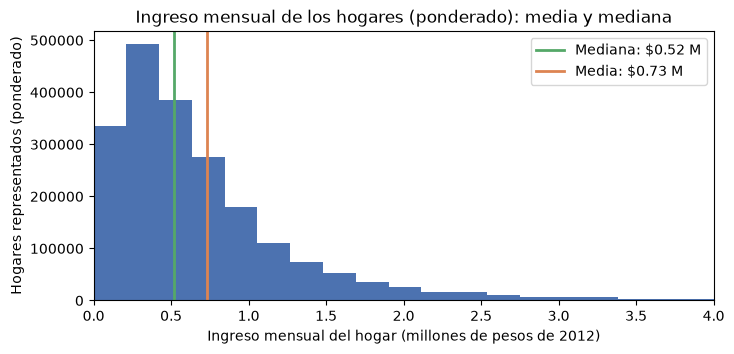

In [29]:
fig, ax = plt.subplots(figsize=(8, 3.5))
#graficvo histogramas
ax.hist(ingreso / 1e6, bins=70, weights=peso_hogar, color="#4C72B0")
ax.axvline(mediana / 1e6, color="#55A868", linewidth=2, label=f"Mediana: ${mediana/1e6:.2f} M")
ax.axvline(media / 1e6, color="#DD8452", linewidth=2, label=f"Media: ${media/1e6:.2f} M")
ax.set_xlim(0, 4)
ax.set_xlabel("Ingreso mensual del hogar (millones de pesos de 2012)")
ax.set_ylabel("Hogares representados (ponderado)")
ax.set_title("Ingreso mensual de los hogares (ponderado): media y mediana")
ax.legend()
plt.show()

## 6. ¿Cuántos viajes hace una persona en un día?

Ya sabemos, por la comparación de merges, que las personas sin viajes no están en la
tabla de viajes. Para contar viajes por persona sin perderlas: agrupar los viajes por
la llave compuesta, y luego alinear ese conteo contra la tabla completa de personas.

In [30]:
viajes_por_persona = viajes.groupby(["Hogar", "Persona"]).size()

conteo = personas.set_index(["Hogar", "Persona"]).assign(n_viajes=viajes_por_persona)["n_viajes"].fillna(0)
conteo


Hogar   Persona 
100010  10001001    2.0
        10001002    5.0
        10001003    0.0
100020  10002001    4.0
        10002002    2.0
                   ... 
706791  70679101    2.0
        70679102    0.0
743813  74381301    2.0
        74381302    2.0
743823  74382301    2.0
Name: n_viajes, Length: 60054, dtype: float64

In [31]:
peso_persona = personas.set_index(["Hogar", "Persona"])["Factor_LaboralNormal"]
peso_persona

Hogar   Persona 
100010  10001001          NaN
        10001002          NaN
        10001003          NaN
100020  10002001    169.50230
        10002002     43.26765
                      ...    
706791  70679101          NaN
        70679102          NaN
743813  74381301          NaN
        74381302          NaN
743823  74382301          NaN
Name: Factor_LaboralNormal, Length: 60054, dtype: float64

In [32]:
validos = peso_persona.notna()
validos



Hogar   Persona 
100010  10001001    False
        10001002    False
        10001003    False
100020  10002001     True
        10002002     True
                    ...  
706791  70679101    False
        70679102    False
743813  74381301    False
        74381302    False
743823  74382301    False
Name: Factor_LaboralNormal, Length: 60054, dtype: bool

In [33]:
media_pond = np.average(conteo[validos], weights=peso_persona[validos])
media_pond

np.float64(2.2298206050579683)

In [34]:
# viajo: True si la persona registra al menos un viaje
df = pd.DataFrame({"viajo": conteo > 0, "peso": peso_persona}).dropna()

# Sin ponderar: proporcion de personas que viajaron y que no (universo laboral).
# El dropna restringe al universo laboral de temporada normal: bota a quienes no
# tienen ese factor (encuestados de fin de semana y de la temporada estival).
muestral = df["viajo"].value_counts(normalize=True)

# Ponderada: la misma cuenta, sumando factores en vez de contar filas.
ponderada = df.groupby("viajo")["peso"].sum() / df["peso"].sum()

# La cifra ingenua: sobre TODAS las personas (incluido el fin de semana), sin pesos.
ingenua = (conteo == 0).mean()


In [35]:
print(f"Promedio ponderado de viajes por persona:      {media_pond:.2f}")
print(f"Cifra ingenua (todas las personas, sin pesos): {ingenua:.1%}")
print(f"Día laboral, sin ponderar:                     {muestral[False]:.1%}")
print(f"Día laboral, ponderado:                        {ponderada[False]:.1%}")


Promedio ponderado de viajes por persona:      2.23
Cifra ingenua (todas las personas, sin pesos): 23.0%
Día laboral, sin ponderar:                     16.2%
Día laboral, ponderado:                        15.1%


Las tres últimas líneas muestran el caso que anunciamos en la sección 3, y conviene
leerlas con cuidado porque la diferencia tiene **dos fuentes distintas**.

La cifra ingenua (23%) calcula sobre todas las personas de la muestra, incluidas las
encuestadas para un sábado o un domingo (días en que se viaja menos) y las encuestadas
en la temporada estival, que tienen sus propios factores: no corresponde a ninguna
población bien definida. Al restringir al universo correcto (personas con
`Factor_LaboralNormal`: día laboral de temporada normal), la cifra sin ponderar baja a
16,2%. Nótese que el código no escribe esa exclusión: SECTRA deja ese factor vacío
para los otros dos grupos, y el `dropna()` los descarta por tener `NaN`; y al ponderar por los
factores, la estimación para un día laboral del Gran Santiago queda en **15,1%**.

La lección es doble: primero hay que definir **sobre qué población** se está
estimando (¿un día laboral? ¿cualquier día?), y después ponderar dentro de ese
universo. Una cifra que omite cualquiera de los dos pasos puede estar contando otra
historia.

La distribución ponderada, ahora sí, describe a la ciudad en un día laboral:

In [36]:
distribucion = conteo[validos].groupby(conteo[validos]).apply(
    lambda g: peso_persona[g.index].sum()
)
(distribucion / distribucion.sum()).head(8).round(3)

n_viajes
0.0    0.151
1.0    0.018
2.0    0.593
3.0    0.052
4.0    0.125
5.0    0.025
6.0    0.021
7.0    0.006
Name: n_viajes, dtype: float64

## 7. ¿Cuánto dura un viaje?

`TiempoViaje` está en minutos, y el peso de cada viaje en `FactorLaboralNormal`.

In [37]:
vd = viajes.dropna(subset=["TiempoViaje", "FactorLaboralNormal"])
duracion, peso_viaje = vd["TiempoViaje"], vd["FactorLaboralNormal"]

print(f"Duración media (ponderada):   {np.average(duracion, weights=peso_viaje):.1f} min")
print(f"Duración mediana (ponderada): {cuantil_ponderado(duracion, peso_viaje, 0.5)[0]:.0f} min")
print(f"Máximo registrado:            {viajes['TiempoViaje'].max():.0f} min")

Duración media (ponderada):   34.7 min
Duración mediana (ponderada): 25 min
Máximo registrado:            1335 min


La mediana dice que el viaje típico dura 25 minutos. El máximo registra más de 1.300
minutos: **un viaje de 22 horas dentro de Santiago**. ¿Error de digitación? ¿Un turno
nocturno mal anotado?

Los valores extremos no se eliminan por incómodos: se investigan, y la decisión que
se tome (mantener, corregir, excluir) se declara en el análisis. Primero, qué tan
raros son:

In [38]:
qs = [0.25, 0.90, 0.95, 0.99, 0.999]
print(pd.Series(cuantil_ponderado(duracion, peso_viaje, qs), index=qs).round(0))


0.250     10.0
0.900     75.0
0.950     90.0
0.990    150.0
0.999    270.0
dtype: float64


In [39]:
sobre_3h = peso_viaje[duracion > 180].sum() / peso_viaje.sum()
print(f"\nViajes de más de 3 horas (ponderado): {sobre_3h:.2%}")


Viajes de más de 3 horas (ponderado): 0.25%


**La decisión, declarada.** Los viajes de más de 3 horas son el 0,25 % del total
ponderado, y hasta el percentil 99,9 la duración no pasa de 270 minutos. En el tramo
de 2 a 4 horas hay viajes verosímiles (a los extremos rurales de la zona encuestada,
en transporte público con esperas); los casos como el máximo de 1.335 minutos
apuntan más bien a errores de registro, por ejemplo un viaje que cruza la medianoche
con la duración calculada sin corregir el cambio de día. Si **los mantenemos y
lo compensamos con la elección de medidas**: reportamos mediana y percentiles, que
no se mueven aunque el máximo sea 1.335 minutos, en lugar de la media (34,7), que sí
queda arrastrada por la cola. Otra opcion es eliminar ese caso.

## 8. ¿En qué se mueve Santiago?

El modo de transporte para difusión está en `ViajesDifusion.csv`, codificado, con su
tabla de parámetros: dos merges y un groupby ponderado.

In [40]:
modo_viaje = pd.read_csv(RUTA + "ViajesDifusion.csv", sep=";")
modo_nombres = pd.read_csv(RUTA + "tablas_parametros/ModoDifusion.csv", sep=";")
modo_viaje

,Viaje,ModoDifusion
0,1000100101,8
1,1000100102,8
2,1000100201,8
3,1000100202,8
4,1000100203,8
...,...,...
113586,7438130102,8
113587,7438130201,8
113588,7438130202,8
113589,7438230101,9


In [41]:
modo_nombres

,ID,ModoDifusion
0,1,Auto
1,2,Bip!
2,3,Taxi Colectivo
3,4,Taxi
4,5,Bip! - Otros Publico
5,6,Bip! - Otros Privado
6,7,Otros
7,8,Caminata
8,9,Bicicleta


In [42]:
# pegar a cada viaje su codigo de modo agregado.
viajes_modo = viajes.merge(modo_viaje, on="Viaje", how="left")

viajes_modo

,Hogar,Persona,Viaje,Etapas,ComunaOrigen,ComunaDestino,SectorOrigen,SectorDestino,ZonaOrigen,ZonaDestino,OrigenCoordX,OrigenCoordY,...,TiempoViaje,TiempoMedio,Periodo,MinutosDespues,CuadrasDespues,FactorLaboralNormal,FactorSabadoNormal,FactorDomingoNormal,FactorLaboralEstival,FactorFindesemanaEstival,CodigoTiempo,ModoDifusion
0,173431,17343102,1734310202,1,94.0,94.0,2.0,2.0,400,407,335208.7188,6288387.0,...,70.0,3.0,6.0,6.0,1.0,1.000000,NaN,NaN,NaN,NaN,0.0,2
1,173441,17344101,1734410101,2,94.0,71.0,2.0,3.0,407,307,338536.4375,6291928.0,...,105.0,4.0,5.0,5.0,1.0,1.127220,NaN,NaN,NaN,NaN,0.0,2
2,173441,17344101,1734410102,2,71.0,94.0,3.0,2.0,307,407,354267.3438,6302297.0,...,90.0,3.0,5.0,10.0,2.0,1.127220,NaN,NaN,NaN,NaN,0.0,2
3,173441,17344103,1734410301,2,94.0,91.0,2.0,3.0,407,437,338536.4375,6291928.0,...,55.0,2.0,5.0,10.0,2.0,1.127220,NaN,NaN,NaN,NaN,0.0,2
4,173441,17344103,1734410302,2,91.0,94.0,3.0,2.0,437,407,350841.6563,6297212.0,...,150.0,5.0,4.0,10.0,2.0,1.052764,NaN,NaN,NaN,NaN,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113586,743813,74381301,7438130102,1,97.0,97.0,5.0,5.0,235,244,349556.9063,6290333.5,...,15.0,1.0,5.0,15.0,4.0,NaN,NaN,1.482104,NaN,NaN,NaN,8
113587,743813,74381302,7438130201,1,97.0,97.0,5.0,5.0,244,235,349410.2813,6289669.0,...,5.0,1.0,3.0,15.0,4.0,NaN,NaN,1.482104,NaN,NaN,NaN,8
113588,743813,74381302,7438130202,1,97.0,97.0,5.0,5.0,235,244,349556.9063,6290333.5,...,15.0,1.0,5.0,15.0,4.0,NaN,NaN,1.482104,NaN,NaN,NaN,8
113589,743823,74382301,7438230101,1,97.0,97.0,5.0,5.0,235,235,NaN,NaN,...,10.0,1.0,2.0,NaN,NaN,NaN,NaN,1.143880,NaN,NaN,NaN,9


In [43]:
# Paso 2: traducir el codigo a su nombre usando el catalogo.
catalogo = modo_nombres.rename(columns={"ID": "ModoDifusion", "ModoDifusion": "NombreModo"})
viajes_modo = viajes_modo.merge(catalogo, on="ModoDifusion", how="left")

print(f"Viajes sin modo asignado: {viajes_modo['NombreModo'].isna().sum()}")

Viajes sin modo asignado: 0


In [44]:
viajes_modo

,Hogar,Persona,Viaje,Etapas,ComunaOrigen,ComunaDestino,SectorOrigen,SectorDestino,ZonaOrigen,ZonaDestino,OrigenCoordX,OrigenCoordY,...,TiempoMedio,Periodo,MinutosDespues,CuadrasDespues,FactorLaboralNormal,FactorSabadoNormal,FactorDomingoNormal,FactorLaboralEstival,FactorFindesemanaEstival,CodigoTiempo,ModoDifusion,NombreModo
0,173431,17343102,1734310202,1,94.0,94.0,2.0,2.0,400,407,335208.7188,6288387.0,...,3.0,6.0,6.0,1.0,1.000000,NaN,NaN,NaN,NaN,0.0,2,Bip!
1,173441,17344101,1734410101,2,94.0,71.0,2.0,3.0,407,307,338536.4375,6291928.0,...,4.0,5.0,5.0,1.0,1.127220,NaN,NaN,NaN,NaN,0.0,2,Bip!
2,173441,17344101,1734410102,2,71.0,94.0,3.0,2.0,307,407,354267.3438,6302297.0,...,3.0,5.0,10.0,2.0,1.127220,NaN,NaN,NaN,NaN,0.0,2,Bip!
3,173441,17344103,1734410301,2,94.0,91.0,2.0,3.0,407,437,338536.4375,6291928.0,...,2.0,5.0,10.0,2.0,1.127220,NaN,NaN,NaN,NaN,0.0,2,Bip!
4,173441,17344103,1734410302,2,91.0,94.0,3.0,2.0,437,407,350841.6563,6297212.0,...,5.0,4.0,10.0,2.0,1.052764,NaN,NaN,NaN,NaN,0.0,2,Bip!
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113586,743813,74381301,7438130102,1,97.0,97.0,5.0,5.0,235,244,349556.9063,6290333.5,...,1.0,5.0,15.0,4.0,NaN,NaN,1.482104,NaN,NaN,NaN,8,Caminata
113587,743813,74381302,7438130201,1,97.0,97.0,5.0,5.0,244,235,349410.2813,6289669.0,...,1.0,3.0,15.0,4.0,NaN,NaN,1.482104,NaN,NaN,NaN,8,Caminata
113588,743813,74381302,7438130202,1,97.0,97.0,5.0,5.0,235,244,349556.9063,6290333.5,...,1.0,5.0,15.0,4.0,NaN,NaN,1.482104,NaN,NaN,NaN,8,Caminata
113589,743823,74382301,7438230101,1,97.0,97.0,5.0,5.0,235,235,NaN,NaN,...,1.0,2.0,NaN,NaN,NaN,NaN,1.143880,NaN,NaN,NaN,9,Bicicleta


In [45]:
reparto = (
    viajes_modo.dropna(subset=["FactorLaboralNormal"])
    .groupby("NombreModo")["FactorLaboralNormal"].sum()
    .sort_values(ascending=False)
)
(reparto / reparto.sum()).round(3)

NombreModo
Caminata                0.339
Bip!                    0.242
Auto                    0.234
Otros                   0.069
Bicicleta               0.038
Taxi Colectivo          0.034
Bip! - Otros Publico    0.019
Taxi                    0.016
Bip! - Otros Privado    0.009
Name: FactorLaboralNormal, dtype: float64

Esta es la **partición modal** del Gran Santiago en día laboral, una cifra de
referencia en la planificación de transporte, calculada aquí desde los microdatos:
la caminata concentra un tercio de los viajes.

### ¿Se mueve igual toda la ciudad?

El total esconde diferencias entre comunas. Para verlas: agregamos la comuna del
hogar a cada viaje (otro merge), simplificamos los modos a cuatro categorías, y
normalizamos por comuna para comparar proporciones.

In [46]:
def agrupar_modo(modo):
    if modo == "Caminata":
        return "Caminata"
    if isinstance(modo, str) and modo.startswith("Bip!"):
        return "Transporte público"
    if modo == "Auto":
        return "Auto"
    return "Otros"

viajes_modo = viajes_modo.merge(hogares[["Hogar", "Comuna"]], on="Hogar", how="left")
viajes_modo["Modo4"] = viajes_modo["NombreModo"].map(agrupar_modo)

viajes_modo[[ "FactorLaboralNormal", "Modo4", "Comuna"]].head(5)

,FactorLaboralNormal,Modo4,Comuna
0,1.000000,Transporte público,MAIPU
1,1.127220,Transporte público,MAIPU
2,1.127220,Transporte público,MAIPU
3,1.127220,Transporte público,MAIPU
4,1.052764,Transporte público,MAIPU


In [47]:
modo_comuna = viajes_modo.pivot_table(
    index="Comuna", columns="Modo4", values="FactorLaboralNormal",
    aggfunc="sum", fill_value=0,
)
modo_comuna = modo_comuna.div(modo_comuna.sum(axis=1), axis=0)

modo_comuna

Modo4,Auto,Caminata,Otros,Transporte público
Comuna,,,,
BUIN,0.171863,0.363214,0.429595,0.035328
CALERA DE TANGO,0.320593,0.267283,0.352010,0.060114
CERRILLOS,0.228555,0.335355,0.123277,0.312813
CERRO NAVIA,0.097537,0.421282,0.090662,0.390520
COLINA,0.071525,0.419525,0.459675,0.049275
CONCHALI,0.095722,0.270223,0.085597,0.548457
EL BOSQUE,0.129629,0.464296,0.156685,0.249390
EL MONTE,0.096948,0.325528,0.498466,0.079058
ESTACION CENTRAL,0.134429,0.449183,0.091011,0.325376


In [48]:
# Las cinco comunas con mayor y menor uso de transporte público
orden_tp = modo_comuna.sort_values("Transporte público")
pd.concat([orden_tp.head(5), orden_tp.tail(5)]).round(2)

Modo4,Auto,Caminata,Otros,Transporte público
Comuna,,,,
BUIN,0.17,0.36,0.43,0.04
COLINA,0.07,0.42,0.46,0.05
MELIPILLA,0.13,0.31,0.50,0.06
CALERA DE TANGO,0.32,0.27,0.35,0.06
LAMPA,0.17,0.44,0.33,0.07
RENCA,0.15,0.34,0.15,0.37
CERRO NAVIA,0.10,0.42,0.09,0.39
LO PRADO,0.07,0.43,0.10,0.40
LA PINTANA,0.08,0.32,0.12,0.48


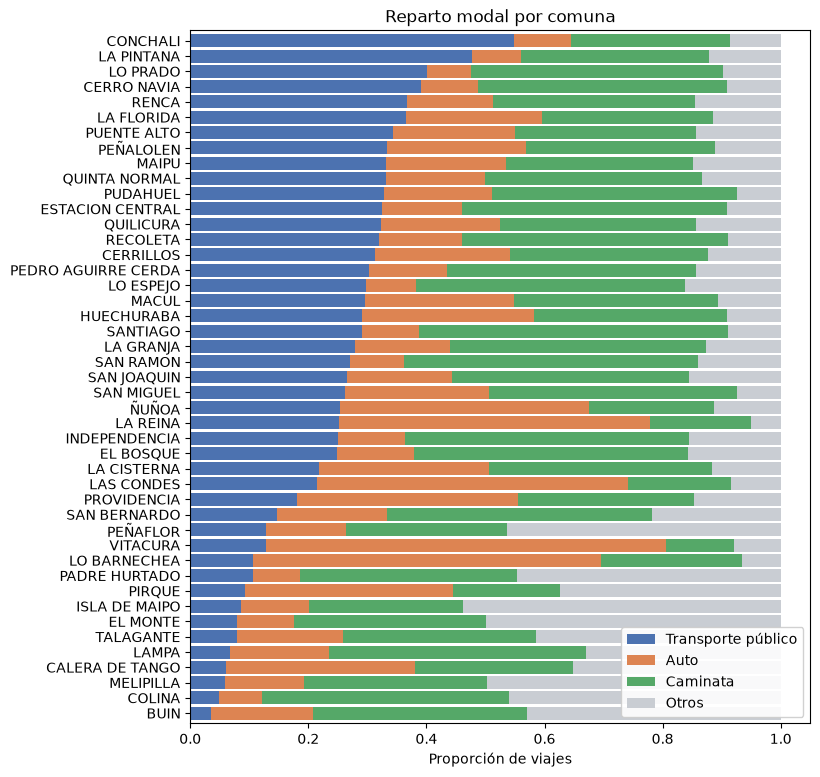

In [49]:
fig, ax = plt.subplots(figsize=(8, 9))
orden_tp[["Transporte público", "Auto", "Caminata", "Otros"]].plot(
    kind="barh", stacked=True, ax=ax,
    color=["#4C72B0", "#DD8452", "#55A868", "#C9CDD3"], width=0.85,
)
ax.set_xlabel("Proporción de viajes")
ax.set_ylabel("")
ax.set_title("Reparto modal por comuna")
ax.legend(loc="lower right", framealpha=0.9)
plt.show()

### El coeficiente de correlación

### Pearson y Spearman: qué mide cada uno

El coeficiente de **Pearson**, mide la asociación
**lineal**: qué tan bien se ajustan los puntos a una recta. Es la covarianza
estandarizada,

$$r = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_i (x_i - \bar{x})^2}\; \sqrt{\sum_i (y_i - \bar{y})^2}}$$

Cada observación aporta el producto de sus desviaciones respecto de la media. De esa
construcción se desprenden sus tres propiedades: un valor extremo entra multiplicando
y puede dominar el resultado; una relación curva produce un coeficiente bajo aunque
la asociación sea fuerte; y transformar los datos cambia su valor.

El coeficiente de **Spearman** es el mismo Pearson, pero calculado sobre los
**rangos**: la posición de cada valor al ordenar la variable. Sin empates equivale a

$$\rho = 1 - \frac{6 \sum_i d_i^2}{n(n^2 - 1)}$$

donde $d_i$ es la diferencia entre los rangos de la observación $i$ en ambas
variables. Al trabajar con posiciones en vez de magnitudes, mide cuán consistente es
que al crecer una variable crezca la otra, **sin importar la forma de la relación**.
Primero, veamos qué le hace el paso a rangos a un valor extremo:

In [50]:
valores = pd.Series([5, 12, 8, 200])
pd.DataFrame({"valor": valores, "rango": valores.rank().astype(int)})

,valor,rango
0,5,1
1,12,3
2,8,2
3,200,4


El 200, por extremo que sea, queda reducido a "el cuarto de cuatro": su magnitud
desaparece y solo sobrevive su posición.

Con dos variables, el cálculo completo es: ordenar cada variable por separado,
asignar los rangos, restar los rangos de cada caso ($d_i$) y aplicar la fórmula.
Con cinco viajes reales de la EOD:

In [51]:
distancias = pd.read_csv(RUTA + "DistanciaViaje.csv", sep=";", decimal=",")
par = viajes.merge(distancias, on="Viaje", how="left")[["DistEuclidiana", "TiempoViaje"]].dropna()
par = par[(par["DistEuclidiana"] > 0) & (par["TiempoViaje"] > 0)]
par


,DistEuclidiana,TiempoViaje
0,5387,70.0
1,18841,105.0
2,18841,90.0
3,13392,55.0
4,13392,150.0
...,...,...
113584,122,8.0
113585,680,15.0
113586,680,15.0
113587,680,5.0


In [52]:
cinco = par.sample(5, random_state=1)
cinco

,DistEuclidiana,TiempoViaje
28522,17848,90.0
105134,188,20.0
80526,492,5.0
30225,5032,60.0
110153,8662,75.0


In [53]:
ejemplo = pd.DataFrame({
    "distancia_km": (cinco["DistEuclidiana"] / 1000).round(1),
    "duracion_min": cinco["TiempoViaje"].astype(int),
})


In [54]:
ejemplo["rango_dist"] = ejemplo["distancia_km"].rank().astype(int)
ejemplo["rango_dur"] = ejemplo["duracion_min"].rank().astype(int)
ejemplo["d"] = ejemplo["rango_dist"] - ejemplo["rango_dur"]
ejemplo["d2"] = ejemplo["d"] ** 2
ejemplo.sort_values("distancia_km")

,distancia_km,duracion_min,rango_dist,rango_dur,d,d2
105134,0.2,20,1,2,-1,1
80526,0.5,5,2,1,1,1
30225,5.0,60,3,3,0,0
110153,8.7,75,4,4,0,0
28522,17.8,90,5,5,0,0


In [55]:
n = len(ejemplo)
rho_manual = 1 - 6 * ejemplo["d2"].sum() / (n * (n**2 - 1))
rho_pandas = ejemplo["distancia_km"].corr(ejemplo["duracion_min"], method="spearman")

print(f"rho con la fórmula: {rho_manual:.2f}")
print(f"rho según pandas:   {rho_pandas:.2f}")

rho con la fórmula: 0.90
rho según pandas:   0.90


Los rangos de este ejemplo casi coinciden (solo los dos viajes cortos intercambian
posiciones), así que $\sum d_i^2 = 2$ y $\rho = 0{,}90$: un orden casi
perfectamente consistente. La fórmula manual y `pandas` entregan lo mismo. De ahí las propiedades de Spearman: es
robusto a valores extremos, no cambia ante transformaciones monótonas (aplicar
logaritmo no altera el orden), y como solo necesita orden, **es válido para
variables ordinales** como el nivel educacional, donde Pearson no tiene sentido.

Comparemos ambos coeficientes en un par de variables que deberían estar
relacionadas: la distancia de un viaje y su duración. Nota metodológica: las
correlaciones se calculan sobre los viajes observados, sin ponderar, porque aquí el
interés es la **forma de la relación**, no una cifra poblacional. Nos quedamos con los viajes de
distancia y duración positivas, que además necesitaremos para el logaritmo.

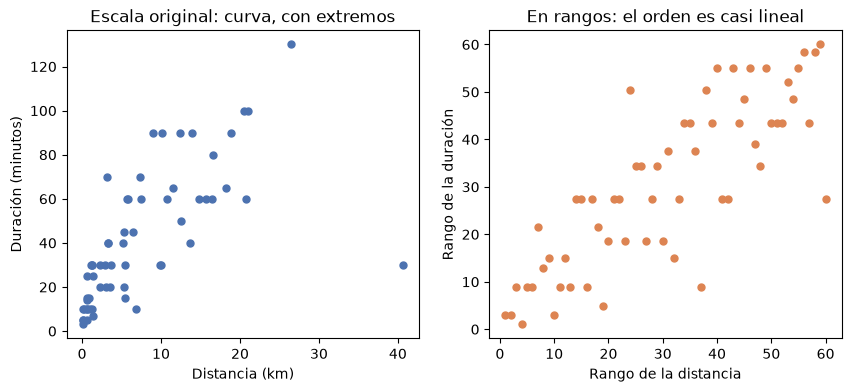

In [56]:
muestra = par.sample(60, random_state=3)
rangos = muestra.rank()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.scatter(muestra["DistEuclidiana"] / 1000, muestra["TiempoViaje"], s=25, color="#4C72B0")
ax1.set_xlabel("Distancia (km)")
ax1.set_ylabel("Duración (minutos)")
ax1.set_title("Escala original: curva, con extremos")

ax2.scatter(rangos["DistEuclidiana"], rangos["TiempoViaje"], s=25, color="#DD8452")
ax2.set_xlabel("Rango de la distancia")
ax2.set_ylabel("Rango de la duración")
ax2.set_title("En rangos: el orden es casi lineal")
plt.show()

In [57]:
import numpy as np

print(f"Viajes considerados: {len(par):,}")
print(f"Pearson:  {par['DistEuclidiana'].corr(par['TiempoViaje']):.2f}")
print(f"Spearman: {par['DistEuclidiana'].corr(par['TiempoViaje'], method='spearman'):.2f}")

Viajes considerados: 102,284
Pearson:  0.43
Spearman: 0.76


La brecha entre 0,43 y 0,76 es grande, y **esa brecha ya es información**: dice que
la relación es claramente creciente (Spearman alto) pero no lineal o con extremos
que distorsionan (Pearson bajo). Podemos verlo pasando una muestra de viajes a
rangos:

Y la verificación final: si la brecha se debe a la curvatura, una transformación
que enderece la curva debería acercar Pearson a Spearman. El logaritmo, al comprimir
los valores grandes, hace exactamente eso:

In [58]:
r_log = np.log(par["DistEuclidiana"]).corr(np.log(par["TiempoViaje"]))
print(f"Pearson sobre log(distancia) y log(duración): {r_log:.2f}")

Pearson sobre log(distancia) y log(duración): 0.73


Pearson sube de 0,43 a 0,73, casi el valor de Spearman. El logaritmo enderezó la
curva y Pearson recuperó la asociación que Spearman veía desde el principio, porque
Spearman es invariante a esa transformación. La curvatura tiene una explicación de
transporte: los viajes largos usan modos más rápidos (metro, autopistas), así que la
duración crece menos que proporcionalmente con la distancia.

**Cuándo usar cada uno.** Pearson cuando ambas variables son numéricas, el gráfico
se ve aproximadamente recto y no hay extremos dominantes; además su cuadrado
anticipa el R² de la regresión lineal (unidad 7). Spearman con distribuciones
asimétricas o con extremos, relaciones curvas pero crecientes, o variables
ordinales. En la práctica del EDA: calcular ambos, y si difieren mucho, mirar el
gráfico antes de reportar cualquiera.

### Cuando la relación no es monótona, ambos coeficientes fallan

Queda un caso importante: relaciones fuertes que suben y luego bajan. En la EOD, los
viajes por persona según la edad tienen esa forma. Usamos el conteo de viajes que
calculamos antes (con los ceros incluidos):

In [59]:
edad_viajes = pd.DataFrame({
    "Edad": personas.set_index(["Hogar", "Persona"])["Edad"],
    "n_viajes": conteo,
})
edad_viajes = edad_viajes[(edad_viajes["Edad"] >= 0) & (edad_viajes["Edad"] <= 95)]

print(f"Pearson:  {edad_viajes['Edad'].corr(edad_viajes['n_viajes']):.2f}")
print(f"Spearman: {edad_viajes['Edad'].corr(edad_viajes['n_viajes'], method='spearman'):.2f}")

Pearson:  0.04
Spearman: 0.05


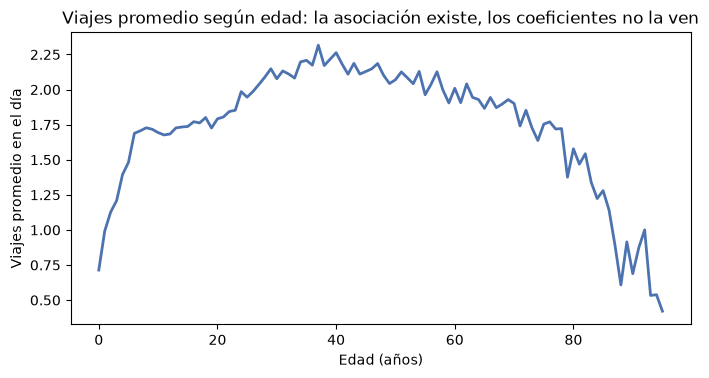

In [60]:
curva_edad = edad_viajes.groupby("Edad")["n_viajes"].mean()

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(curva_edad.index, curva_edad.values, color="#4C72B0", linewidth=2)
ax.set_xlabel("Edad (años)")
ax.set_ylabel("Viajes promedio en el día")
ax.set_title("Viajes promedio según edad: la asociación existe, los coeficientes no la ven")
plt.show()

Ambos coeficientes quedan cerca de cero, y sin embargo el gráfico muestra una
asociación clara: los viajes suben hasta los 30 a 40 años y luego caen. La relación
no es monótona, así que el tramo creciente y el decreciente se cancelan: ni Pearson
(que busca una recta) ni Spearman (que busca un orden consistente) están diseñados
para esta forma.

La conclusión que hay que retener: **un coeficiente cercano a cero no demuestra
ausencia de asociación**. Demuestra ausencia de asociación *lineal* (Pearson) o
*monotónica* (Spearman); la forma completa solo se ve en el gráfico.


## 9. ¿Cambian las rutinas durante la semana?

Cada hogar tiene asignado un día (`DiaAsig` en la tabla de hogares). Con el propósito
del viaje y el factor del día correspondiente podemos comparar las rutinas de lunes a
domingo. Un **heatmap** muestra la tabla completa de una vez.

In [61]:
proposito = pd.read_csv(RUTA + "tablas_parametros/Proposito.csv", sep=";")

rutinas = (
    viajes.merge(hogares[["Hogar", "DiaAsig"]], on="Hogar", how="left")
    .merge(proposito, left_on="Proposito", right_on="Id", how="left",
           suffixes=("_codigo", ""))
)

# Cada día usa su propia expansión: laboral, sábado o domingo (temporada normal).
rutinas["peso"] = (
    rutinas["FactorLaboralNormal"]
    .fillna(rutinas["FactorSabadoNormal"])
    .fillna(rutinas["FactorDomingoNormal"])
)
rutinas = rutinas.dropna(subset=["peso", "Proposito"])

# Igual que con los modos: una funcion con la decision de agrupacion.
def agrupar_proposito(proposito):
    if proposito in ("Al trabajo", "Por trabajo"):
        return "Trabajo"
    if proposito in ("Al estudio", "Por estudio"):
        return "Estudio"
    return proposito

rutinas["Proposito"] = rutinas["Proposito"].map(agrupar_proposito)

# Aparte, cosmetica de etiquetas: solo mayusculas y un parentesis, no cambia grupos.
rutinas["Proposito"] = rutinas["Proposito"].replace({
    "volver a casa": "Volver a casa",
    "Buscar o Dejar a alguien": "Buscar o dejar a alguien",
    "Comer o Tomar algo": "Comer o tomar algo",
    "Otra actividad (especifique)": "Otra actividad",
})

rutinas[["Hogar", "Proposito","DiaAsig","peso"]].head(5)

,Hogar,Proposito,DiaAsig,peso
0,173431,Volver a casa,jueves,1.000000
1,173441,Trabajo,miércoles,1.127220
2,173441,Volver a casa,miércoles,1.127220
3,173441,Trabajo,miércoles,1.127220
4,173441,Volver a casa,miércoles,1.052764


In [62]:
#defino una lista para que la tabla quede ordenada por los días de la semana, no por orden alfabético
dias = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]

tabla_rutinas = rutinas.pivot_table(
    index="Proposito", columns="DiaAsig", values="peso", aggfunc="sum", fill_value=0,
)[dias]

tabla_rutinas


DiaAsig,lunes,martes,miércoles,jueves,viernes,sábado,domingo
Proposito,,,,,,,
Buscar o dejar a alguien,638.486747,778.239670,934.986654,975.725797,1127.727919,225.549850,158.946395
Buscar o dejar algo,82.423707,102.265707,117.888885,100.144209,122.088604,46.654893,38.215349
Comer o tomar algo,104.715942,123.776698,176.046094,161.282998,182.948357,75.572627,64.058792
De compras,1178.956924,1494.661495,2015.703252,1663.943115,1996.375324,1980.236099,1819.542166
De salud,272.872197,369.254992,504.920830,404.366780,412.079196,130.882123,54.532133
Estudio,1573.536125,1866.951250,2173.631477,2012.001304,2477.356315,155.219071,63.799877
Otra actividad,206.171703,259.101929,295.547876,281.051989,391.532883,295.678157,290.534988
Recreación,183.788405,271.413452,326.739949,307.003060,569.483471,756.285817,683.631903
Trabajo,2537.182066,3142.502319,3766.975869,3424.642753,4091.397786,1313.977593,645.740377


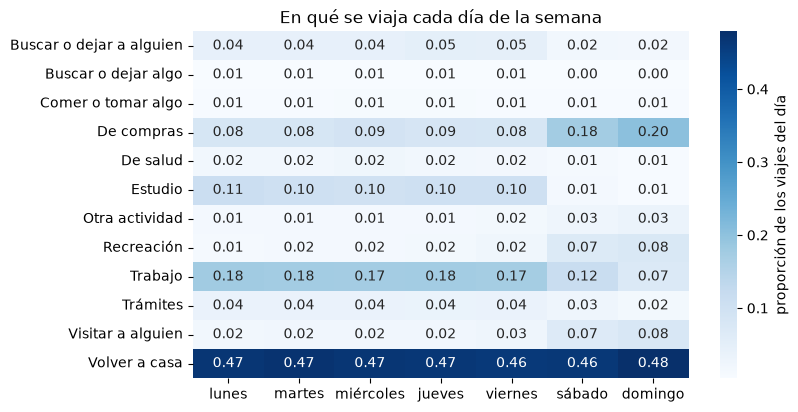

In [63]:
# Proporción de los viajes de cada día (columnas suman 1)
tabla_rutinas = tabla_rutinas / tabla_rutinas.sum()

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(tabla_rutinas, cmap="Blues", annot=True, fmt=".2f",
            cbar_kws={"label": "proporción de los viajes del día"}, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("En qué se viaja cada día de la semana")
plt.show()

Lectura del heatmap: el regreso a casa es cerca de la mitad de los viajes todos los
días (casi todo viaje tiene su vuelta). De lunes a viernes dominan trabajo y estudio;
el fin de semana suben compras, recreación y visitas. La ventaja del heatmap es que
esa comparación completa (14 propósitos por 7 días) cabe en una sola figura legible.

## 10. Una nota sobre el tamaño: Pandas no es para todo

Pandas carga todo en la memoria del computador. Para la EOD (47 MB) sobra; para los
microdatos del Censo 2017 (17,5 millones de personas) o registros de decenas de
gigabytes, se queda sin memoria. Existen herramientas con la misma lógica de tablas
para esos tamaños: **Polars** (sintaxis similar a Pandas, en paralelo), **DuckDB**
(SQL sobre archivos, sin cargar todo), **Dask** y **PySpark** (datos distribuidos).
Las ideas de esta clase (llaves, merge, groupby, factores) son las mismas en todas;
más adelante en el curso las veremos con más detalle.

## 11. Síntesis: ¿de quién habla este número?

Repasamos las herramientas (merge, groupby, describe), pero el aprendizaje de hoy es
la pregunta. Aplíquenla a lo que hicimos:

- *"El hogar promedio gana $730 mil"*: la mayoría de los hogares gana menos; la
  mediana ($520 mil) y los percentiles describen mejor al hogar típico.
- *"El 23% no viajó"*: esa cifra ingenua mezclaba días de fin de semana y omitía los
  factores; la estimación correcta para un día laboral es el **15%**.
- *"Las personas hacen 2,2 viajes en promedio"*: solo si contamos a las que no
  viajaron. Un `merge` con `how="inner"` las habría excluido del cálculo.
- *"En Vitacura casi no se usa transporte público"*: es un promedio comunal, y
  esconde la variación interna de la comuna.

Las operaciones eran repaso; lo nuevo es examinar qué representa cada cifra.

## Referencias y créditos

- SECTRA, Ministerio de Transportes (2014). *Encuesta Origen Destino de Viajes
  Santiago 2012*. https://www.sectra.gob.cl/biblioteca/detalle1.asp?mfn=3253
- El enfoque de este notebook (preguntas sobre la ciudad con la EOD y el uso de los
  factores de expansión) está inspirado en el material del curso de visualización de
  Eduardo Graells-Garrido: https://github.com/zorzalerrante/aves
- Bruce, P., Bruce, A. y Gedeck, P. (2020). *Practical Statistics for Data
  Scientists*, 2ª ed. O'Reilly. Capítulo 1.
- Chambers, J. M. y Hastie, T. J. (1992). *Statistical Models in S*. Wadsworth &
  Brooks/Cole.
- Horvitz, D. G. y Thompson, D. J. (1952). *A Generalization of Sampling Without
  Replacement from a Finite Universe*. Journal of the American Statistical
  Association, 47(260), 663-685.
- McKinney, W. (2010). *Data Structures for Statistical Computing in Python*.
  Proceedings of the 9th Python in Science Conference.